# Transformers

* Building an encoder-decoder Transformer to translate English words to Spanish.

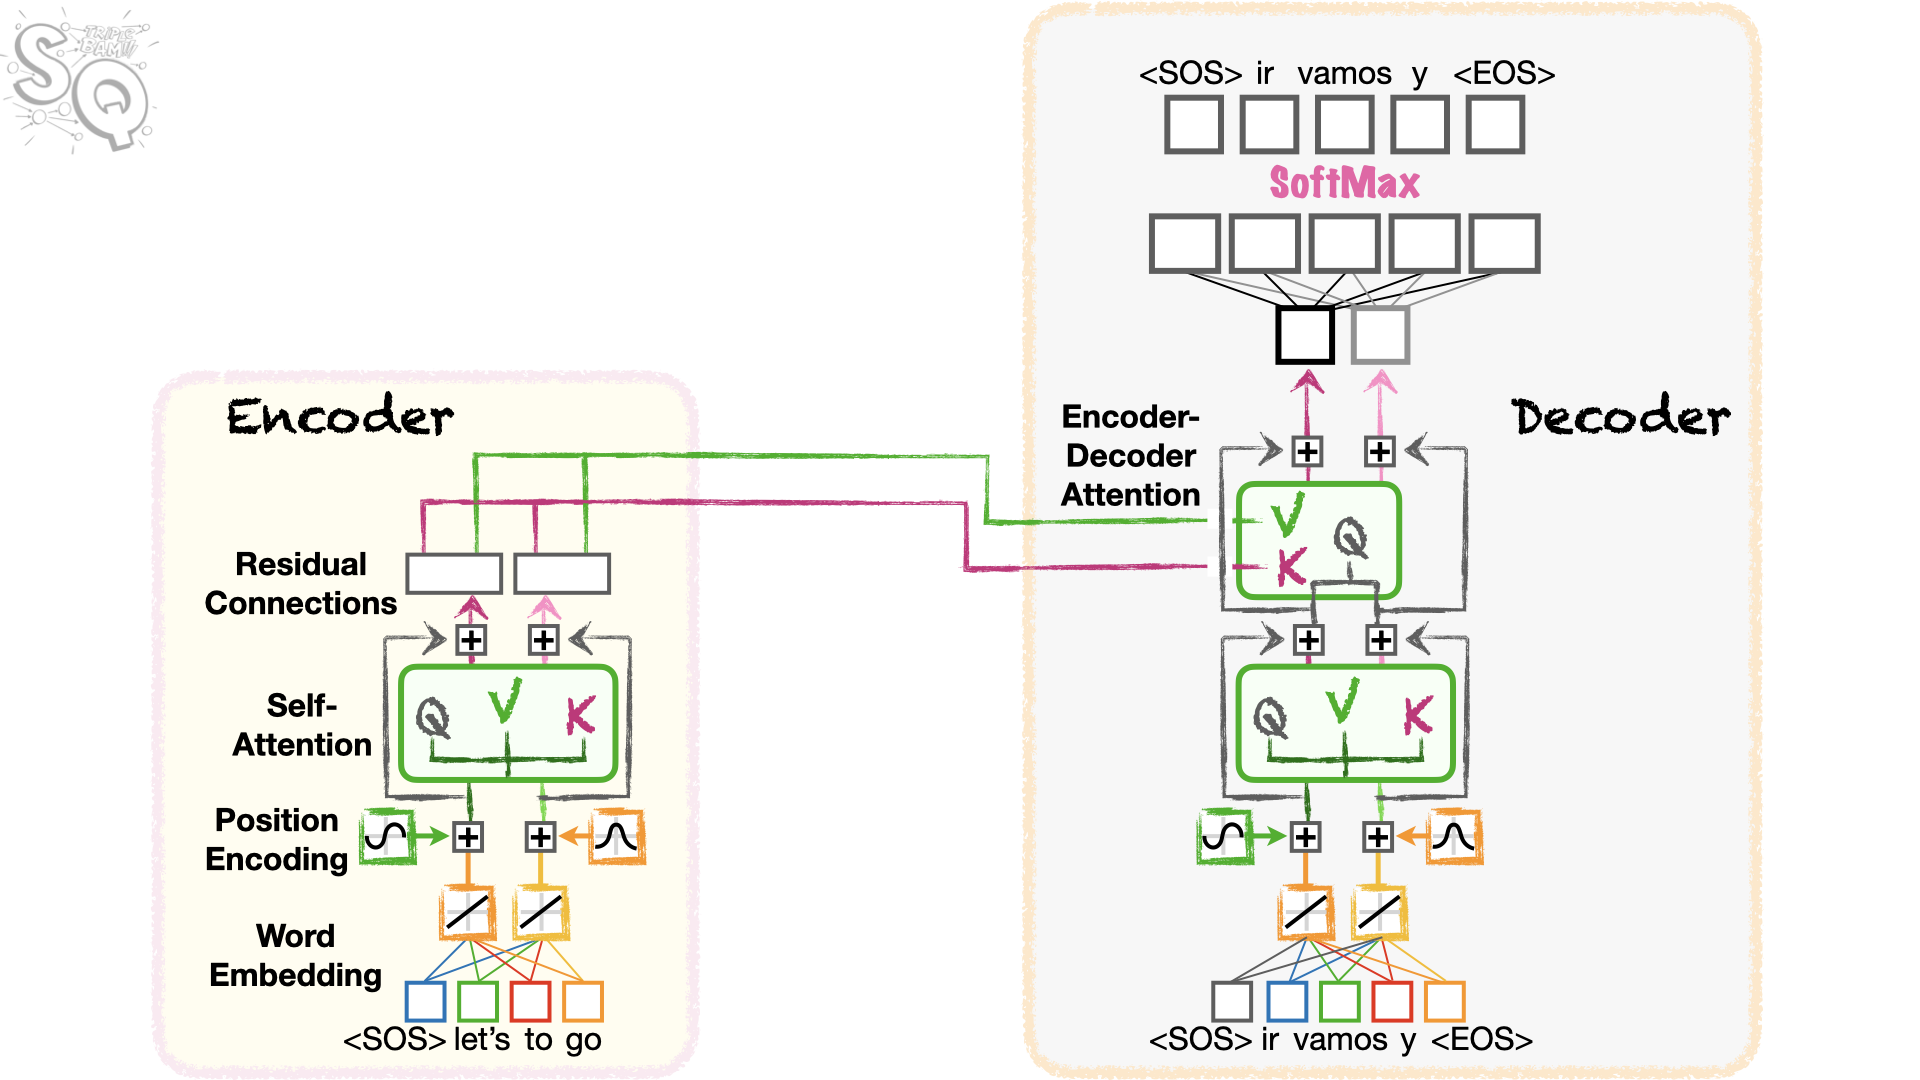

## 1. Vocabulary

* Each word/token is assigned an integer ID.

In [16]:
import torch 
import torch.nn as nn
import lightning as L 

# ============================================================
# VOCABULARIES
# ============================================================

# Input vocabulary (English)
input_vocab = {
    '<SOS>': 0,   # Start of sequence
    'lets': 1,
    'to': 2,
    'go': 3
}

# Output vocabulary (Spanish)
output_vocab = {
    '<SOS>': 0,   # Start of sequence
    'ir': 1,
    'vamos': 2,
    'y': 3,
    '<EOS>': 4    # End of sequence
}

In [17]:
input_vocab

{'<SOS>': 0, 'lets': 1, 'to': 2, 'go': 3}

In [18]:
output_vocab

{'<SOS>': 0, 'ir': 1, 'vamos': 2, 'y': 3, '<EOS>': 4}

## 2. Input Words and Labels

* StatQuest’s original word IDs are kept here. The model will prepend <SOS> to the input and decoder sequences.

In [19]:
# English phrases:
# ["lets go", "to go"]
inputs = torch.tensor([
    [1, 3],
    [2, 3]
])

# Spanish translations:
# ["vamos", "ir"]
labels = torch.tensor([
    [2],
    [1]
])

In [20]:
inputs

tensor([[1, 3],
        [2, 3]])

In [21]:
labels

tensor([[2],
        [1]])

## 3. Positional Encoding

* A Transformer needs information about token order. Word embeddings tell the model what the tokens are; positional encoding tells it where they occur in the sequence.

In [26]:
class PositionalEncoding(nn.Module):
  
  def __init__(self, d_model, max_len=5000):
    super().__init__()
    
    # Create a positional encoding matrix.
    # Shape: (max_len, d_model)
    position = torch.arange(max_len).unsqueeze(1)
    
    # Frequencies used for the sine/cosine pattern.
    div_term = torch.exp(
        torch.arange(0, d_model, 2) *
        (-torch.log(torch.tensor(10000.0)) / d_model)
    )

    pe = torch.zeros(max_len, d_model)

    # Even dimensions use sine.
    pe[:, 0::2] = torch.sin(position * div_term)

    # Odd dimensions use cosine.
    pe[:, 1::2] = torch.cos(position * div_term)

    # Shape becomes (1, max_len, d_model) so it can be
    # added to a batch of embeddings.
    pe = pe.unsqueeze(0)

    # Store as a buffer rather than a trainable parameter.
    self.register_buffer('pe', pe)
    

  def forward(self, x):
      # Add positional information to the word embeddings.
      return x + self.pe[:, :x.size(1)]

## 4. Transformer Model
* We build the embeddings, positional encoding, and final output layer ourselves.

* The actual Transformer architecture is provided by PyTorch’s built-in nn.Transformer.

In [27]:
class TransformerModel(L.LightningModule):

    def __init__(self):
        super().__init__()

        # ====================================================
        # EMBEDDING DIMENSION
        # ====================================================
        self.d_model = 4

        # ====================================================
        # 1. INPUT WORD EMBEDDING
        # ====================================================
        # English token IDs -> embedding vectors
        self.input_embedding = nn.Embedding(
            num_embeddings=len(input_vocab),
            embedding_dim=self.d_model
        )

        # ====================================================
        # 2. OUTPUT WORD EMBEDDING
        # ====================================================
        # Spanish token IDs -> embedding vectors
        self.output_embedding = nn.Embedding(
            num_embeddings=len(output_vocab),
            embedding_dim=self.d_model
        )

        # ====================================================
        # 3. POSITIONAL ENCODING
        # ====================================================
        # Tells the Transformer where each token occurs
        # in the sequence.
        self.input_positional_encoding = PositionalEncoding(
            self.d_model
        )

        self.output_positional_encoding = PositionalEncoding(
            self.d_model
        )

        # ====================================================
        # 4. BUILT-IN PYTORCH TRANSFORMER
        # ====================================================
        self.transformer = nn.Transformer(
            d_model=self.d_model,
            nhead=2,
            num_encoder_layers=1,
            num_decoder_layers=1,
            batch_first=True
        )

        # nn.Transformer handles:
        #
        # ENCODER
        #   - Self-Attention
        #   - Feed-Forward Network
        #   - Residual Connections
        #   - Layer Normalization
        #
        # DECODER
        #   - Masked Self-Attention
        #   - Encoder-Decoder / Cross-Attention
        #   - Feed-Forward Network
        #   - Residual Connections
        #   - Layer Normalization

        # ====================================================
        # 5. FINAL LINEAR / OUTPUT LAYER
        # ====================================================
        # 4-dimensional Transformer output
        # -> 5 output vocabulary scores
        self.output_layer = nn.Linear(
            self.d_model,
            len(output_vocab)
        )

        # ====================================================
        # 6. LOSS FUNCTION
        # ====================================================
        self.loss = nn.CrossEntropyLoss()


    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, inputs, labels):

        # ====================================================
        # ENCODER
        # ====================================================

        # ----------------------------------------------------
        # 1. PREPEND <SOS> TO ENGLISH INPUT
        # ----------------------------------------------------

        # Original:
        # [lets, go]
        # [to,   go]
        #
        # Becomes:
        # [<SOS>, lets, go]
        # [<SOS>, to,   go]

        sos_input = torch.full(
            (inputs.size(0), 1),
            input_vocab['<SOS>'],
            dtype=inputs.dtype,
            device=inputs.device
        )

        encoder_input = torch.cat(
            (sos_input, inputs),
            dim=1
        )

        # ----------------------------------------------------
        # 2. INPUT WORD EMBEDDING
        # ----------------------------------------------------

        input_embeddings = self.input_embedding(
            encoder_input
        )

        # ----------------------------------------------------
        # 3. INPUT POSITIONAL ENCODING
        # ----------------------------------------------------

        input_embeddings = self.input_positional_encoding(
            input_embeddings
        )


        # ====================================================
        # DECODER
        # ====================================================

        # ----------------------------------------------------
        # 4. PREPEND <SOS> TO SPANISH INPUT
        # ----------------------------------------------------

        # Labels:
        # [vamos]
        # [ir]
        #
        # Becomes:
        # [<SOS>, vamos]
        # [<SOS>, ir]

        sos_output = torch.full(
            (labels.size(0), 1),
            output_vocab['<SOS>'],
            dtype=labels.dtype,
            device=labels.device
        )

        decoder_input = torch.cat(
            (sos_output, labels),
            dim=1
        )

        # ----------------------------------------------------
        # 5. OUTPUT WORD EMBEDDING
        # ----------------------------------------------------

        output_embeddings = self.output_embedding(
            decoder_input
        )

        # ----------------------------------------------------
        # 6. OUTPUT POSITIONAL ENCODING
        # ----------------------------------------------------

        output_embeddings = self.output_positional_encoding(
            output_embeddings
        )

        # ----------------------------------------------------
        # 7. CAUSAL / LOOK-AHEAD MASK
        # ----------------------------------------------------

        # Prevents the decoder from looking at future tokens.
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            decoder_input.size(1)
        ).to(labels.device)


        # ====================================================
        # 8. BUILT-IN TRANSFORMER
        # ====================================================

        transformer_output = self.transformer(
            src=input_embeddings,
            tgt=output_embeddings,
            tgt_mask=tgt_mask
        )

        # PyTorch handles internally:
        #
        # Encoder:
        #   Self-Attention
        #        ↓
        #   Feed-Forward Network
        #
        # Decoder:
        #   Masked Self-Attention
        #        ↓
        #   Encoder-Decoder / Cross-Attention
        #        ↓
        #   Feed-Forward Network
        #
        # Plus:
        #   Residual Connections
        #   Layer Normalization


        # ====================================================
        # 9. FINAL LINEAR OUTPUT
        # ====================================================

        logits = self.output_layer(
            transformer_output
        )

        return logits


    # ========================================================
    # TRAINING STEP
    # ========================================================

    def training_step(self, batch, batch_idx):

        inputs, labels = batch

        # Get predictions
        logits = self(
            inputs,
            labels
        )

        # ----------------------------------------------------
        # TARGET OUTPUT
        # ----------------------------------------------------

        # Decoder input:
        #
        # [<SOS>, vamos]
        # [<SOS>, ir]
        #
        # Desired predictions:
        #
        # [vamos, <EOS>]
        # [ir,    <EOS>]

        eos = torch.full(
            (labels.size(0), 1),
            output_vocab['<EOS>'],
            dtype=labels.dtype,
            device=labels.device
        )

        target = torch.cat(
            (labels, eos),
            dim=1
        )

        # ----------------------------------------------------
        # CROSS-ENTROPY LOSS
        # ----------------------------------------------------

        loss = self.loss(
            logits.reshape(-1, len(output_vocab)),
            target.reshape(-1)
        )

        self.log(
            "train_loss",
            loss
        )

        return loss


    # ========================================================
    # OPTIMIZER
    # ========================================================

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.01
        )

## 7. DataLoader

In [28]:
dataset = torch.utils.data.TensorDataset(
    inputs,
    labels
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=False
)

In [29]:
transformer = TransformerModel()

trainer = L.Trainer(
    max_epochs=30
)

trainer.fit(
    transformer,
    train_dataloaders=dataloader
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name                       | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------------------------
0 | input_embedding            | Embedding          | 16     | train | 0    
1 | output_embedding           | Embedding          | 20     | train | 0    
2 | input_positional_encoding  | PositionalEncoding | 0      | train | 0    
3 | output_positional_encoding | PositionalEncoding | 0      | train | 0    
4 | transformer                | Transformer        | 37.2 K | train | 0    
5 | output_layer               | Linear             | 25     | train | 0    
6 | loss                       | CrossEntropyLoss   | 0      | train | 0    
----------------------------------------------------------------------------------
37.2 K    Tr

Epoch 29: 100%|██████████| 1/1 [00:00<00:00, 52.83it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 1/1 [00:00<00:00, 18.22it/s, v_num=1]
